In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# import scipy.io
from poisson_glm_granger import compute_granger_causality, compute_optimal_lags
# from joblib import Parallel, delayed
from statsmodels.stats.multitest import multipletests
import pickle
import copy

In [8]:
def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

In [9]:
conditions=['GO','SS','FS']

In [13]:
n_q=3
unit_labels=[]
region_labels=['C3','F4']
region_pcs={
    'C3': [2,4],
    'F4': [5,10]
}
for region in region_labels:
    for pc in region_pcs[region]:
        for q in range(n_q):
            unit_labels.append(f'{region}-PC{pc+1}-Q{q+1}')
n_units=len(unit_labels)

In [14]:
unit_labels

['C3-PC3-Q1',
 'C3-PC3-Q2',
 'C3-PC3-Q3',
 'C3-PC5-Q1',
 'C3-PC5-Q2',
 'C3-PC5-Q3',
 'F4-PC6-Q1',
 'F4-PC6-Q2',
 'F4-PC6-Q3',
 'F4-PC11-Q1',
 'F4-PC11-Q2',
 'F4-PC11-Q3']

In [16]:
t1_signed_gc_matrices={
    condition: np.zeros((n_units, n_units))*np.nan for condition in conditions
}
t1_diff_gc_matrices=np.zeros((n_units, n_units))*np.nan
t1_p_values_diff=np.zeros((n_units, n_units))*np.nan
for c3_pc in region_pcs['C3']:
    for f4_pc in region_pcs['F4']:
        fname=f'/home/qmoreau/schmidt_data/output/connectivity_t1_c3pc{c3_pc+1}_f4pc{f4_pc+1}.npz'
        data=np.load(fname, allow_pickle=True)
        pc_unit_labels=data['unit_labels'][()]
        pc_n_units=len(pc_unit_labels)
        for condition in conditions:
            pc_signed_gc_matrix=np.mean(np.array(data['signed_gc_matrices'][()][condition]),axis=0)
            for pc_i in range(pc_n_units):
                for pc_j in range(pc_n_units):
                    i=unit_labels.index(pc_unit_labels[pc_i])
                    j=unit_labels.index(pc_unit_labels[pc_j])
                    t1_signed_gc_matrices[condition][i,j]=pc_signed_gc_matrix[pc_i,pc_j]
        pc_diff_gc_matrices=np.mean(data['diff_gc_matrices'][()],axis=0)
        pc_p_values_diff=data['p_values_diff'][()]
        for pc_i in range(pc_n_units):
            for pc_j in range(pc_n_units):
                i=unit_labels.index(pc_unit_labels[pc_i])
                j=unit_labels.index(pc_unit_labels[pc_j])
                t1_diff_gc_matrices[i,j] = pc_diff_gc_matrices[pc_i,pc_j]
                t1_p_values_diff[i,j] = pc_p_values_diff[pc_i,pc_j]

In [17]:
t2_signed_gc_matrices={
    condition: np.zeros((n_units, n_units))*np.nan for condition in conditions
}
t2_diff_gc_matrices=np.zeros((n_units, n_units))*np.nan
t2_p_values_diff=np.zeros((n_units, n_units))*np.nan
for c3_pc in region_pcs['C3']:
    for f4_pc in region_pcs['F4']:
        fname=f'./output/connectivity_t2_c3pc{c3_pc+1}_f4pc{f4_pc+1}.npz'
        data=np.load(fname, allow_pickle=True)
        pc_unit_labels=data['unit_labels'][()]
        pc_n_units=len(pc_unit_labels)
        for condition in conditions:
            pc_signed_gc_matrix=np.mean(np.array(data['signed_gc_matrices'][()][condition]),axis=0)
            for pc_i in range(pc_n_units):
                for pc_j in range(pc_n_units):
                    i=unit_labels.index(pc_unit_labels[pc_i])
                    j=unit_labels.index(pc_unit_labels[pc_j])
                    t2_signed_gc_matrices[condition][i,j]=pc_signed_gc_matrix[pc_i,pc_j]
        pc_diff_gc_matrices=np.mean(data['diff_gc_matrices'][()],axis=0)
        pc_p_values_diff=data['p_values_diff'][()]
        for pc_i in range(pc_n_units):
            for pc_j in range(pc_n_units):
                i=unit_labels.index(pc_unit_labels[pc_i])
                j=unit_labels.index(pc_unit_labels[pc_j])
                t2_diff_gc_matrices[i,j] = pc_diff_gc_matrices[pc_i,pc_j]
                t2_p_values_diff[i,j] = pc_p_values_diff[pc_i,pc_j]

In [18]:
t3_signed_gc_matrices={
    condition: np.zeros((n_units, n_units))*np.nan for condition in conditions
}
t3_diff_gc_matrices=np.zeros((n_units, n_units))*np.nan
t3_p_values_diff=np.zeros((n_units, n_units))*np.nan
for c3_pc in region_pcs['C3']:
    for f4_pc in region_pcs['F4']:
        fname=f'./output/connectivity_t3_c3pc{c3_pc+1}_f4pc{f4_pc+1}.npz'
        data=np.load(fname, allow_pickle=True)
        pc_unit_labels=data['unit_labels'][()]
        pc_n_units=len(pc_unit_labels)
        for condition in conditions:
            pc_signed_gc_matrix=np.mean(np.array(data['signed_gc_matrices'][()][condition]),axis=0)
            for pc_i in range(pc_n_units):
                for pc_j in range(pc_n_units):
                    i=unit_labels.index(pc_unit_labels[pc_i])
                    j=unit_labels.index(pc_unit_labels[pc_j])
                    t3_signed_gc_matrices[condition][i,j]=pc_signed_gc_matrix[pc_i,pc_j]
        pc_diff_gc_matrices=np.mean(data['diff_gc_matrices'][()],axis=0)
        pc_p_values_diff=data['p_values_diff'][()]
        for pc_i in range(pc_n_units):
            for pc_j in range(pc_n_units):
                i=unit_labels.index(pc_unit_labels[pc_i])
                j=unit_labels.index(pc_unit_labels[pc_j])
                t3_diff_gc_matrices[i,j] = pc_diff_gc_matrices[pc_i,pc_j]
                t3_p_values_diff[i,j] = pc_p_values_diff[pc_i,pc_j]

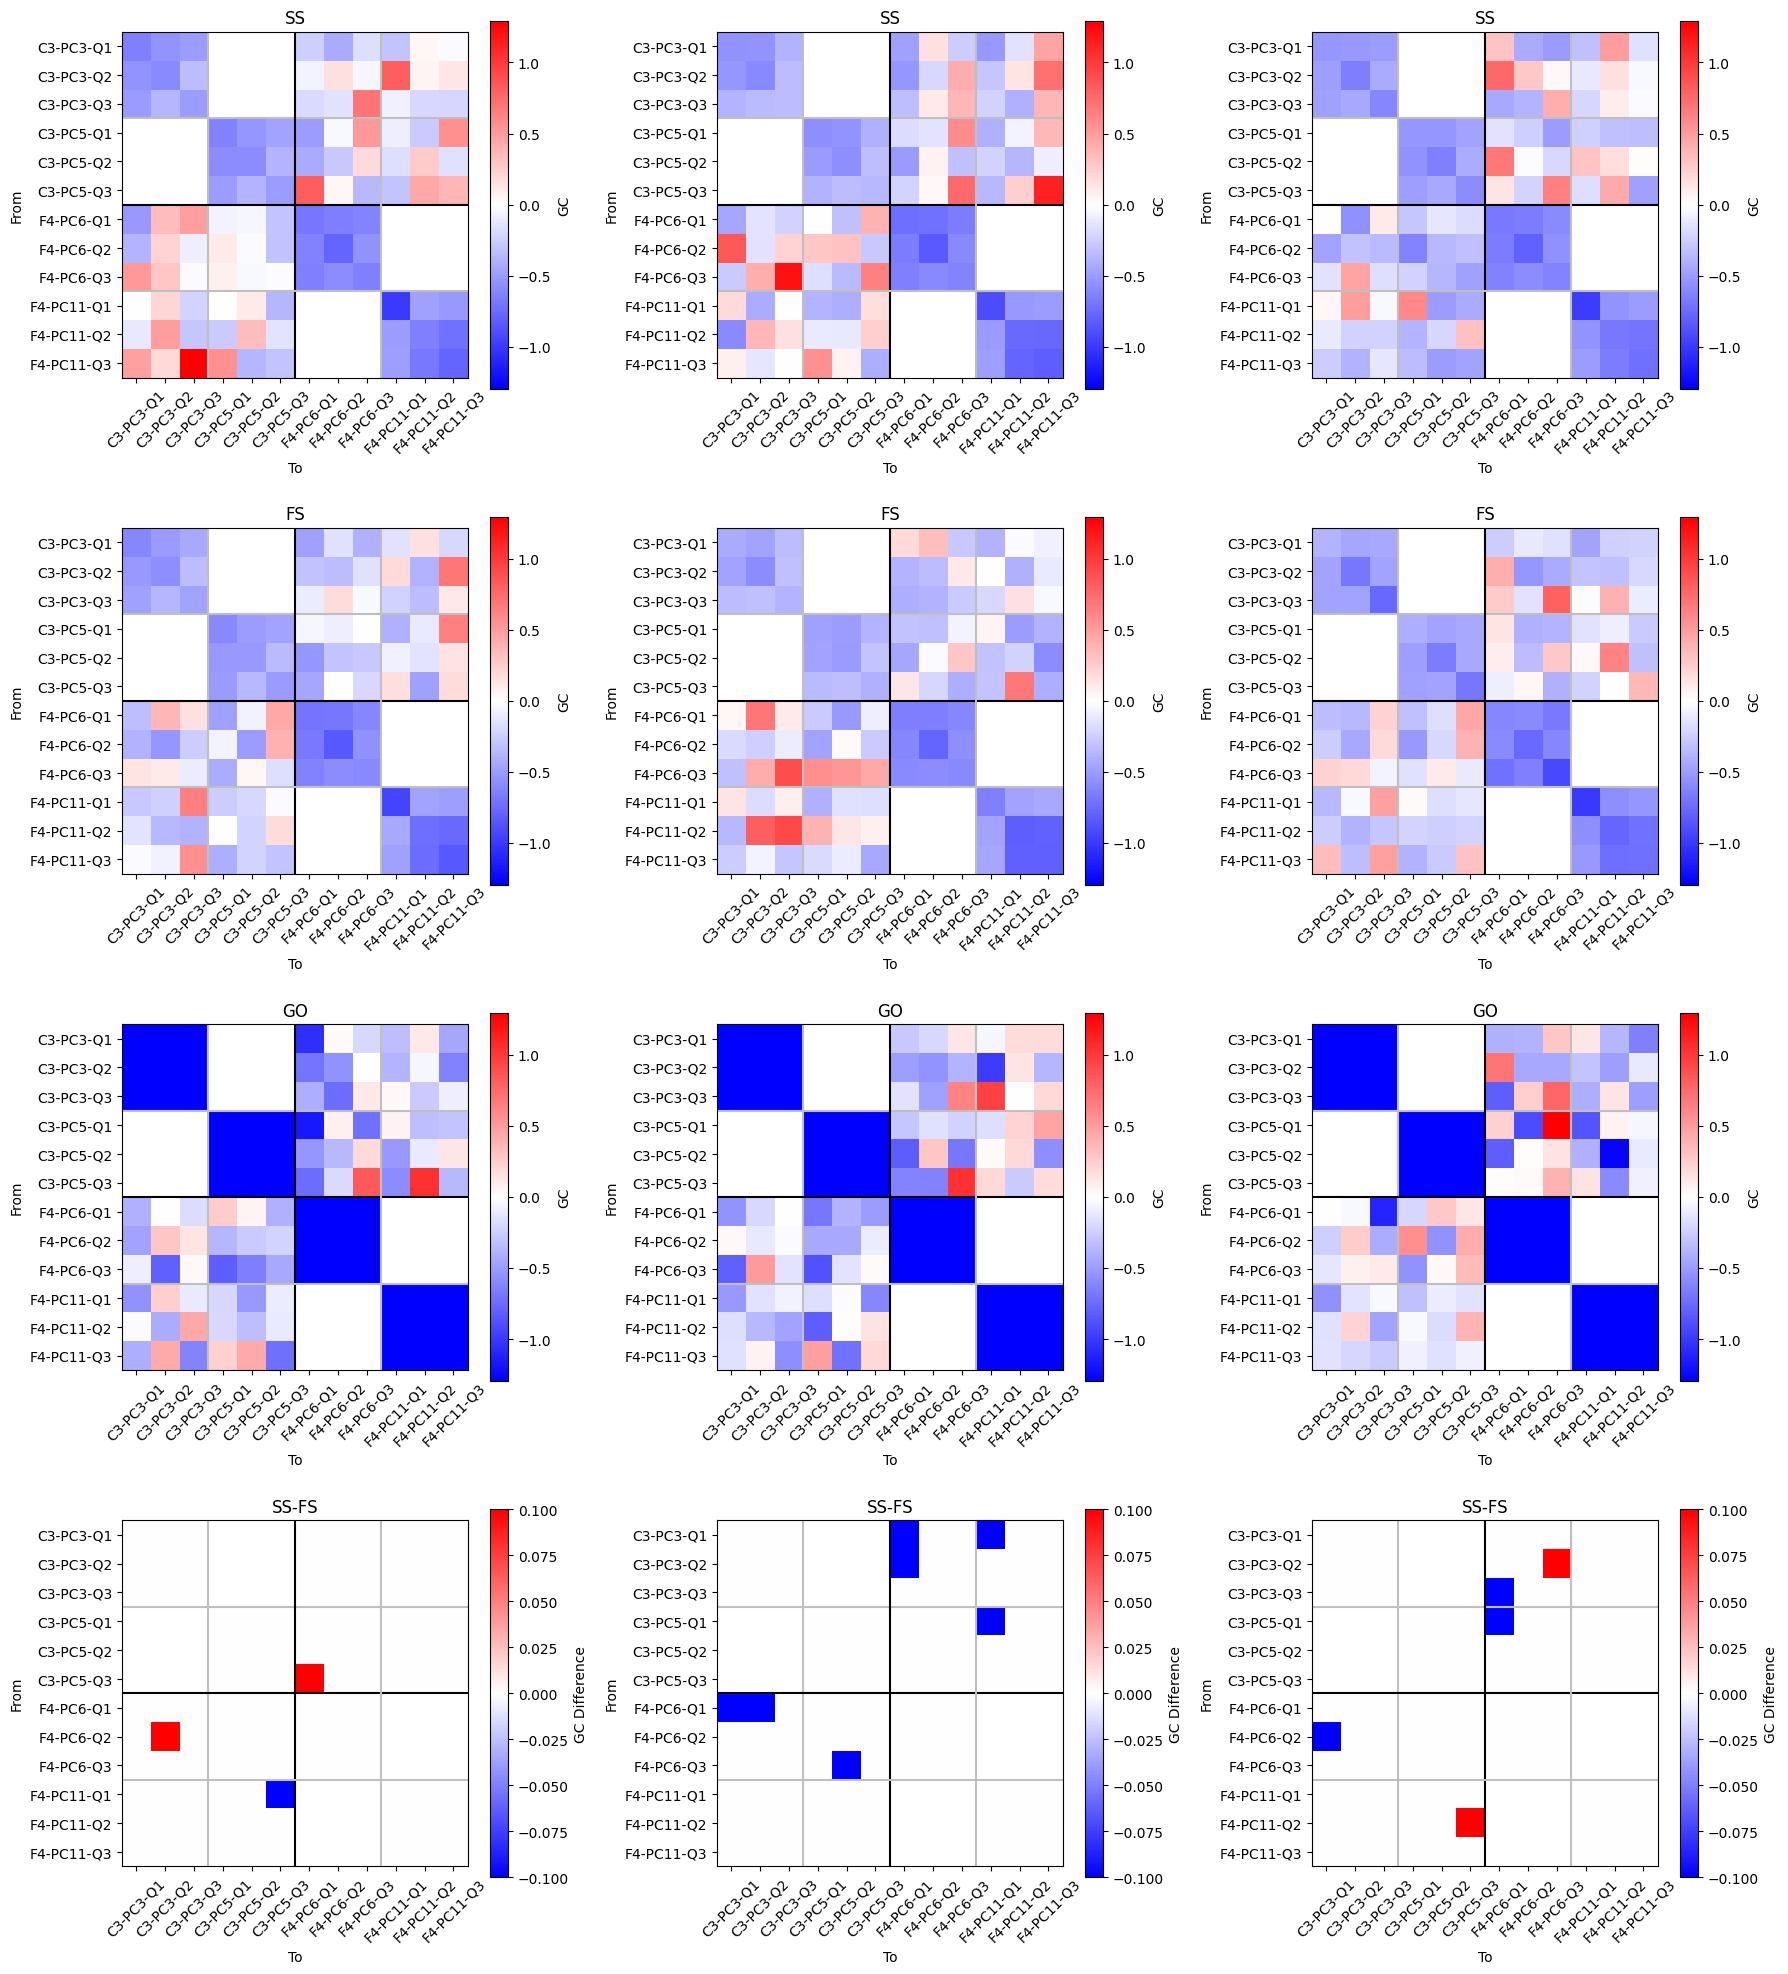

In [19]:
fig = plt.figure(figsize=(18, 20))
gs = GridSpec(4, 3)
# Calculate a dynamic clim based on all conditions
all_gc_values = []
for cond in ['FS','SS']:
    all_gc_values.extend(t1_signed_gc_matrices[cond].flatten())
    all_gc_values.extend(t2_signed_gc_matrices[cond].flatten())
    all_gc_values.extend(t3_signed_gc_matrices[cond].flatten())
common_clim = [-max(abs(np.nanmin(all_gc_values)), np.nanmax(all_gc_values)), max(abs(np.nanmin(all_gc_values)), np.nanmax(all_gc_values))]

ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(t1_signed_gc_matrices['SS'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('SS')

ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(t2_signed_gc_matrices['SS'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('SS')

ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(t3_signed_gc_matrices['SS'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('SS')

ax = fig.add_subplot(gs[1, 0])
# Visualize results
im = ax.imshow(t1_signed_gc_matrices['FS'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('FS')

ax = fig.add_subplot(gs[1, 1])
# Visualize results
im = ax.imshow(t2_signed_gc_matrices['FS'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('FS')

ax = fig.add_subplot(gs[1, 2])
# Visualize results
im = ax.imshow(t3_signed_gc_matrices['FS'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('FS')

ax = fig.add_subplot(gs[2, 0])
# Visualize results
im = ax.imshow(t1_signed_gc_matrices['GO'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('GO')

ax = fig.add_subplot(gs[2, 1])
# Visualize results
im = ax.imshow(t2_signed_gc_matrices['GO'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('GO')

ax = fig.add_subplot(gs[2, 2])
# Visualize results
im = ax.imshow(t3_signed_gc_matrices['GO'], cmap='bwr', interpolation='none', clim=common_clim)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(n_units))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(n_units))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC')
ax.set_title('GO')

# Plot the GC difference
ax = fig.add_subplot(gs[3, 0])
significant_diff_gc_matrix = copy.copy(t1_diff_gc_matrices)
significant_diff_gc_matrix[t1_p_values_diff >= 0.05] = 0
# Dynamic clim based on the difference matrix
maxabs = np.max(np.abs(significant_diff_gc_matrix))
im = ax.imshow(significant_diff_gc_matrix, cmap='bwr', interpolation='none', clim=[-maxabs, maxabs])
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(len(unit_labels)))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(len(unit_labels)))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC Difference')
ax.set_title('SS-FS')

ax = fig.add_subplot(gs[3, 1])
significant_diff_gc_matrix = copy.copy(t2_diff_gc_matrices)
significant_diff_gc_matrix[t2_p_values_diff >= 0.05] = 0
# Dynamic clim based on the difference matrix
maxabs = np.max(np.abs(significant_diff_gc_matrix))
im = ax.imshow(significant_diff_gc_matrix, cmap='bwr', interpolation='none', clim=[-maxabs, maxabs])
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(len(unit_labels)))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(len(unit_labels)))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC Difference')
ax.set_title('SS-FS')

ax = fig.add_subplot(gs[3, 2])
significant_diff_gc_matrix = copy.copy(t3_diff_gc_matrices)
significant_diff_gc_matrix[t3_p_values_diff >= 0.05] = 0
# Dynamic clim based on the difference matrix
maxabs = np.max(np.abs(significant_diff_gc_matrix))
im = ax.imshow(significant_diff_gc_matrix, cmap='bwr', interpolation='none', clim=[-maxabs, maxabs])
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_xticks(np.arange(len(unit_labels)))
ax.set_xticklabels(unit_labels, rotation=45)
ax.set_yticks(np.arange(len(unit_labels)))
ax.set_yticklabels(unit_labels)
plt.axvline(2.5,color=[.75,.75,.75])
plt.axhline(2.5,color=[.75,.75,.75])
plt.axvline(5.5,color='k')
plt.axhline(5.5,color='k')
plt.axvline(8.5,color=[.75,.75,.75])
plt.axhline(8.5,color=[.75,.75,.75])
plt.colorbar(im, label='GC Difference')
ax.set_title('SS-FS')

plt.tight_layout()

plt.savefig('./figures/figure_Sxx_connectivity.pdf')